# Q1 — Sales analysis

Jar Growth Intern assignment. This notebook walks through Question 1 step by step using the **same functions** as `main.py` (in `src/`), so every number here matches the report. Run top to bottom.

`python main.py` regenerates the full report (PDF), all tables and all figures.

In [1]:
import pandas as pd
from IPython.display import Image, display

from src import config as C, data, insights, pipeline, regional, sales, targets

pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 160)

## 0. Load, repair and merge

Both date fields were corrupted by spreadsheet auto-conversion and are repaired in memory (raw files in `data/` are untouched). Every loader asserts its own invariants.

In [2]:
orders = data.load_orders()
details = data.load_details()
tgt = data.load_targets()
print(f'orders {orders.shape}, details {details.shape}, targets {tgt.shape}')
orders[['Order ID', 'Order Date Raw', 'Order Date', 'State', 'City']].head()

orders (500, 6), details (1500, 6), targets (36, 3)


,Order ID,Order Date Raw,Order Date,State,City
0,B-25601,2018-01-04 00:00:00,2018-04-01,Gujarat,Ahmedabad
1,B-25602,2018-01-04 00:00:00,2018-04-01,Maharashtra,Pune
2,B-25603,2018-03-04 00:00:00,2018-04-03,Madhya Pradesh,Bhopal
3,B-25604,2018-03-04 00:00:00,2018-04-03,Rajasthan,Jaipur
4,B-25605,2018-05-04 00:00:00,2018-04-05,West Bengal,Kolkata


**Order Date repair check.** Text cells are `dd-mm-yyyy`; datetime cells had day and month swapped. After repair, dates are monotonic in the sequential Order ID and fall inside FY 2018-19.

In [3]:
by_id = orders.assign(n=orders['Order ID'].str[2:].astype(int)).sort_values('n')
assert by_id['Order Date'].is_monotonic_increasing
orders['Order Date'].agg(['min', 'max'])

min   2018-04-01
max   2019-03-31
Name: Order Date, dtype: datetime64[ns]

**Merge.** Order Details (line grain) is left-joined to List of Orders with `validate='many_to_one'`; the join report proves no line is orphaned or duplicated.

In [4]:
merged, join = data.merge_orders(orders, details)
join.as_frame()

,check,value
0,orders_rows,500
1,details_rows,1500
2,merged_rows,1500
3,orders_unique_ids,500
4,details_unique_ids,500
5,duplicate_ids_in_orders,0
6,ids_only_in_orders,0
7,ids_only_in_details,0
8,join_type,"left (Order Details -> List of Orders), valida..."


## Part 1 — Sales and profitability

*Profit per order* (primary) = category profit ÷ distinct orders containing the category; *profit per line* is shown alongside.

In [5]:
cat = sales.category_summary(merged)
cat[['amount', 'profit', 'orders', 'lines', 'profit_per_order', 'profit_per_line', 'margin_pct',
     'sales_share_pct', 'profit_share_pct']]

,amount,profit,orders,lines,profit_per_order,profit_per_line,margin_pct,sales_share_pct,profit_share_pct
Category,,,,,,,,,
Electronics,165267,10494,204,308,51.44,34.07,6.35,38.30,43.81
Clothing,139054,11163,393,949,28.40,11.76,8.03,32.23,46.60
Furniture,127181,2298,186,243,12.35,9.46,1.81,29.47,9.59


In [6]:
sub = sales.subcategory_summary(merged)
sub[['Category', 'Sub-Category', 'amount', 'profit', 'margin_pct', 'lines', 'loss_line_share_pct']]

,Category,Sub-Category,amount,profit,margin_pct,lines,loss_line_share_pct
0,Clothing,Trousers,30039,2847,9.48,39,38.46
1,Clothing,Stole,18546,2559,13.80,192,27.08
2,Clothing,Hankerchief,14608,2098,14.36,198,21.21
3,Clothing,T-shirt,7382,1500,20.32,77,15.58
4,Clothing,Shirt,7555,1131,14.97,69,17.39
5,Clothing,Saree,53511,352,0.66,210,46.67
6,Clothing,Leggings,2106,260,12.35,53,30.19
7,Clothing,Skirt,1946,235,12.08,64,28.12
8,Clothing,Kurti,3361,181,5.39,47,29.79
9,Electronics,Printers,58252,5964,10.24,74,33.78


**Loss concentration** and the **price-realisation check** (no discount field exists, so realised unit price on loss lines is compared with profitable lines in the same sub-category). Lower realised prices are consistent with discounting *or* a cheaper product mix; the data cannot separate the two.

In [7]:
loss = sales.loss_profile(merged)
loss[['loss_line_share_pct', 'gross_gain', 'gross_loss', 'loss_to_gain_pct', 'top_n_loss_share_pct']]

,loss_line_share_pct,gross_gain,gross_loss,loss_to_gain_pct,top_n_loss_share_pct
Category,,,,,
Clothing,29.40,"23,156.00","11,993.00",51.79,28.65
Electronics,39.61,"27,216.00","16,722.00",61.44,41.50
Furniture,41.98,"17,819.00","15,521.00",87.10,57.57


In [8]:
price = sales.price_realisation(merged)
print(f"loss lines cheaper in {(price['price_ratio_loss_vs_profit'] < 1).sum()} of {len(price)} sub-categories; "
      f"median ratio {price['price_ratio_loss_vs_profit'].median():.2f}x")
price[['Category', 'Sub-Category', 'median_unit_price_loss', 'median_unit_price_profit',
       'price_ratio_loss_vs_profit', 'median_qty_loss', 'median_qty_profit']]

loss lines cheaper in 16 of 17 sub-categories; median ratio 0.55x


,Category,Sub-Category,median_unit_price_loss,median_unit_price_profit,price_ratio_loss_vs_profit,median_qty_loss,median_qty_profit
0,Clothing,Hankerchief,6.67,13.50,0.49,3.00,3.00
1,Clothing,Kurti,10.39,21.00,0.49,4.00,3.00
2,Clothing,Leggings,7.00,13.43,0.52,3.50,3.00
3,Clothing,Saree,30.75,51.50,0.60,3.00,3.00
4,Clothing,Shirt,13.42,31.68,0.42,3.50,3.00
5,Clothing,Skirt,4.38,9.22,0.47,2.50,3.00
6,Clothing,Stole,14.67,26.67,0.55,3.00,3.00
7,Clothing,T-shirt,12.17,23.80,0.51,3.50,4.00
8,Clothing,Trousers,248.00,89.67,2.77,3.00,3.00
9,Electronics,Accessories,25.65,71.33,0.36,3.00,3.00


## Part 2 — Furniture target achievement

Flag rule: a month is flagged when its MoM % lies more than `FLUCTUATION_Z` standard deviations from the series mean; a materiality cross-check flags |MoM| ≥ `MATERIAL_MOM_PCT`.

In [9]:
print('z threshold:', C.FLUCTUATION_Z, '| materiality %:', C.MATERIAL_MOM_PCT)
mom = targets.target_mom(tgt)
mom

z threshold: 1.5 | materiality %: 5.0


,Month,Target,mom_abs,mom_pct,mom_z,flag_relative,flag_material
0,2018-04-01,"10,400.00",NaN,NaN,NaN,False,False
1,2018-05-01,"10,500.00",100.00,0.96,-0.46,False,False
2,2018-06-01,"10,600.00",100.00,0.95,-0.48,False,False
3,2018-07-01,"10,800.00",200.00,1.89,1.74,True,False
4,2018-08-01,"10,900.00",100.00,0.93,-0.55,False,False
5,2018-09-01,"11,000.00",100.00,0.92,-0.57,False,False
6,2018-10-01,"11,100.00",100.00,0.91,-0.59,False,False
7,2018-11-01,"11,300.00",200.00,1.80,1.54,True,False
8,2018-12-01,"11,400.00",100.00,0.88,-0.65,False,False
9,2019-01-01,"11,500.00",100.00,0.88,-0.66,False,False


In [10]:
monthly = sales.category_monthly(merged)
tva = targets.target_vs_actual(tgt, monthly)
print(f"annual attainment {100 * tva['Actual'].sum() / tva['Target'].sum():.1f}%, "
      f"months met {(tva['Actual'] >= tva['Target']).sum()} of 12")
tva[['Month', 'Target', 'Actual', 'gap', 'attainment_pct', 'Profit', 'margin_pct']]

annual attainment 95.7%, months met 4 of 12


,Month,Target,Actual,gap,attainment_pct,Profit,margin_pct
0,2018-04-01,"10,400.00",8121,"-2,279.00",78.09,-3425,-42.17
1,2018-05-01,"10,500.00",6220,"-4,280.00",59.24,-794,-12.77
2,2018-06-01,"10,600.00",5532,"-5,068.00",52.19,-856,-15.47
3,2018-07-01,"10,800.00",3483,"-7,317.00",32.25,-457,-13.12
4,2018-08-01,"10,900.00",9538,"-1,362.00",87.50,443,4.64
5,2018-09-01,"11,000.00",8704,"-2,296.00",79.13,-2468,-28.35
6,2018-10-01,"11,100.00",6766,"-4,334.00",60.95,-1316,-19.45
7,2018-11-01,"11,300.00",15165,"3,865.00",134.20,3945,26.01
8,2018-12-01,"11,400.00",9474,"-1,926.00",83.11,187,1.97
9,2019-01-01,"11,500.00",21257,"9,757.00",184.84,3284,15.45


**Re-phasing.** Same annual target, spread by company-wide seasonality. Company sales include Furniture, so leakage is partial; the ex-Furniture variant removes it.

In [11]:
all_sales = merged.groupby('Month')['Amount'].sum()
other = merged[merged['Category'] != C.TARGET_CATEGORY].groupby('Month')['Amount'].sum()
rp, rpx = targets.rephased_targets(tva, all_sales), targets.rephased_targets(tva, other)
pd.Series({'MAPE current target': targets.mape(rp['Actual'], rp['Target']),
           'MAPE re-phased (company-wide)': targets.mape(rp['Actual'], rp['Rephased']),
           'MAPE re-phased (ex-Furniture)': targets.mape(rpx['Actual'], rpx['Rephased'])})

MAPE current target             54.40
MAPE re-phased (company-wide)   19.45
MAPE re-phased (ex-Furniture)   27.27
dtype: float64

## Part 3 — Regional performance

Order count = **distinct Order IDs** (from List of Orders). Average profit is **per order**.

In [12]:
states = regional.state_summary(orders, merged)
top = regional.top_states(states)
top[['orders', 'sales', 'profit', 'profit_per_order', 'profit_per_line', 'margin_pct']]

,orders,sales,profit,profit_per_order,profit_per_line,margin_pct
State,,,,,,
Madhya Pradesh,101,105140,5551,54.96,16.33,5.28
Maharashtra,90,95348,6176,68.62,21.30,6.48
Rajasthan,32,21149,1257,39.28,16.99,5.94
Gujarat,27,21058,465,17.22,5.34,2.21
Punjab,25,16786,-609,-24.36,-10.15,-3.63


In [13]:
states[['orders', 'sales', 'profit', 'margin_pct', 'sales_share_pct', 'profit_share_pct', 'share_gap_pp']]

,orders,sales,profit,margin_pct,sales_share_pct,profit_share_pct,share_gap_pp
State,,,,,,,
Madhya Pradesh,101,105140,5551,5.28,24.37,23.17,-1.19
Maharashtra,90,95348,6176,6.48,22.10,25.78,3.68
Rajasthan,32,21149,1257,5.94,4.90,5.25,0.35
Gujarat,27,21058,465,2.21,4.88,1.94,-2.94
Punjab,25,16786,-609,-3.63,3.89,-2.54,-6.43
Delhi,22,22531,2987,13.26,5.22,12.47,7.25
Uttar Pradesh,22,22359,3237,14.48,5.18,13.51,8.33
West Bengal,22,14086,2500,17.75,3.26,10.44,7.17
Karnataka,21,15058,645,4.28,3.49,2.69,-0.80


In [14]:
cities = regional.city_summary(orders, merged)
focus = set(top.index) | set(states.index[states['profit'] < 0])
cities[cities['State'].isin(focus)][['State', 'City', 'orders', 'sales', 'profit', 'margin_pct',
                                     'share_of_state_sales_pct']]

,State,City,orders,sales,profit,margin_pct,share_of_state_sales_pct
0,Andhra Pradesh,Hyderabad,15,13256,-496,-3.74,100.00
1,Bihar,Patna,16,12943,-321,-2.48,100.00
4,Gujarat,Ahmedabad,17,14230,-880,-6.18,67.58
5,Gujarat,Surat,10,6828,1345,19.70,32.42
11,Madhya Pradesh,Indore,76,79069,4159,5.26,75.20
12,Madhya Pradesh,Bhopal,22,23583,871,3.69,22.43
13,Madhya Pradesh,Delhi,3,2488,521,20.94,2.37
14,Maharashtra,Mumbai,68,61867,1637,2.65,64.89
15,Maharashtra,Pune,22,33481,4539,13.56,35.11
17,Punjab,Chandigarh,16,12279,-1153,-9.39,73.15


## Consistency with the report pipeline

The tables above must equal what `main.py` computes; then the report figures are rendered.

In [15]:
t = pipeline.compute()
for name, df in {'cat': cat, 'sub': sub, 'loss': loss, 'price': price, 'mom': mom,
                 'tva': tva, 'states': states, 'cities': cities}.items():
    pd.testing.assert_frame_equal(df, t[name])
print('All notebook tables identical to the pipeline output.')

All notebook tables identical to the pipeline output.


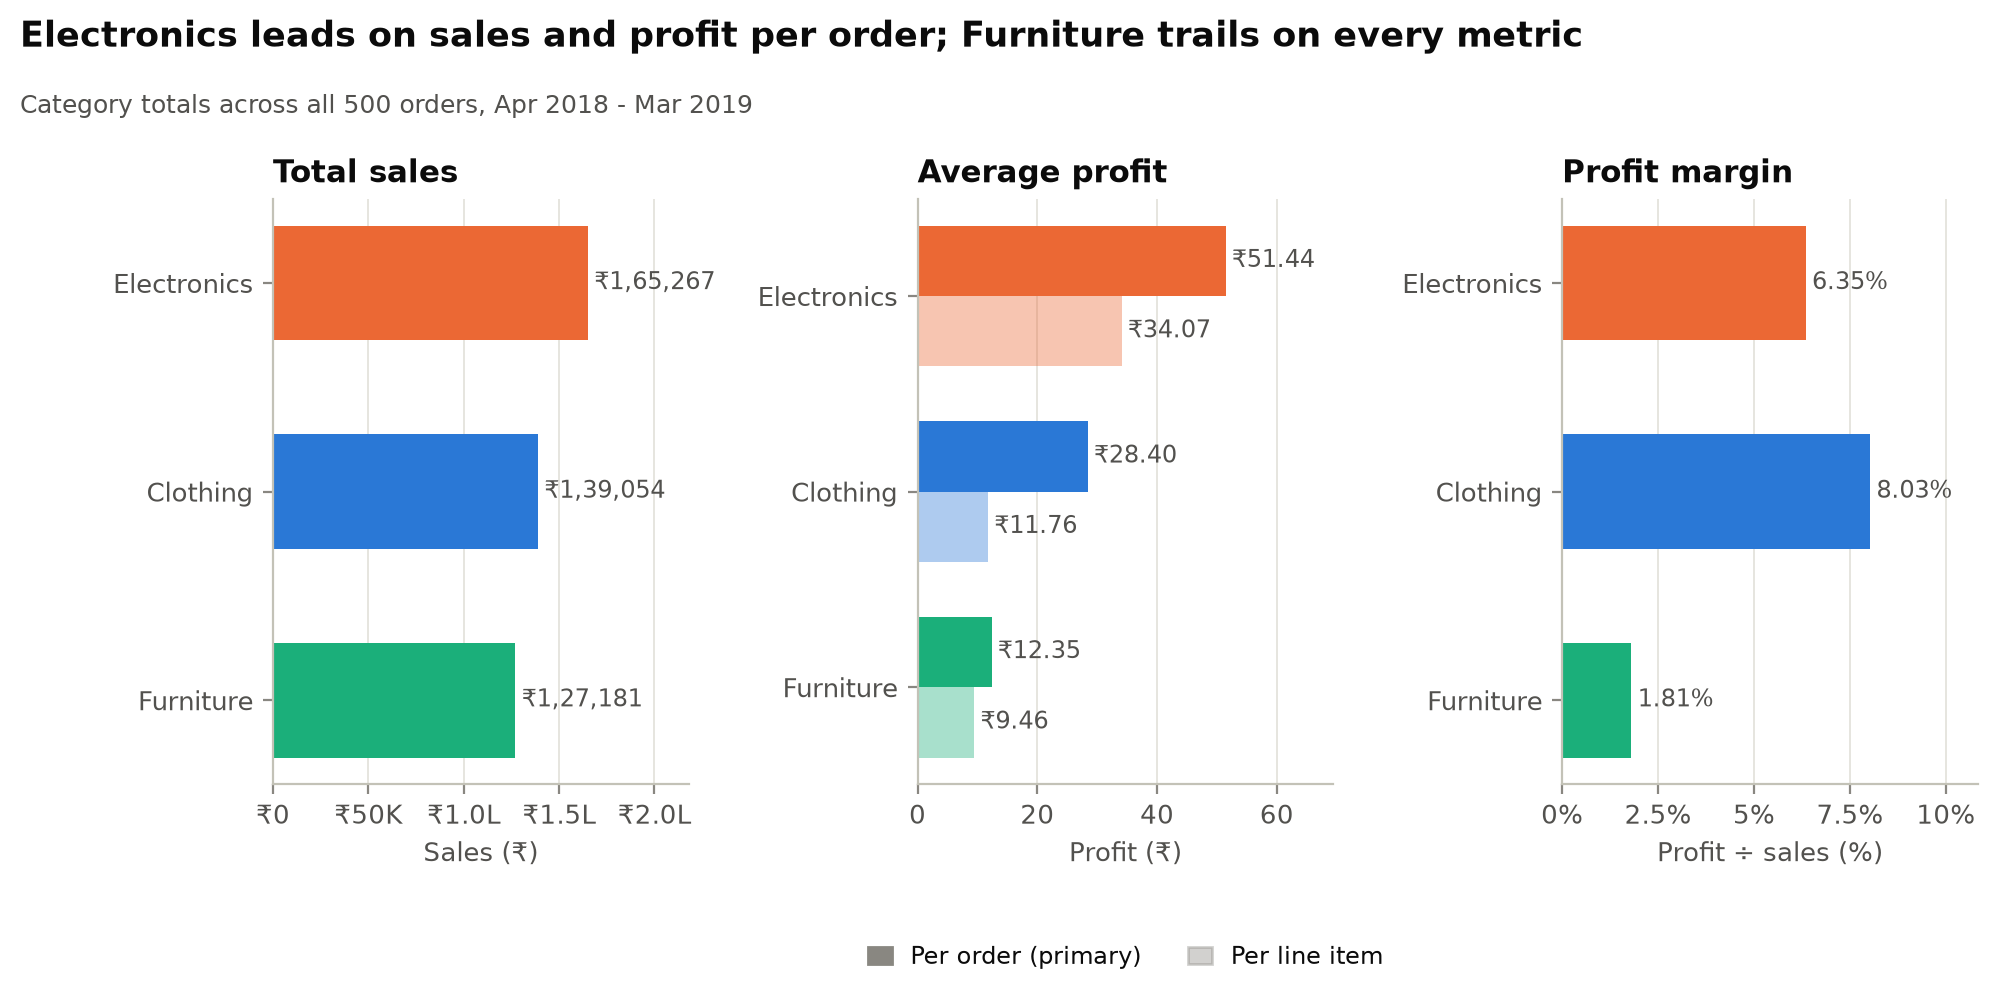

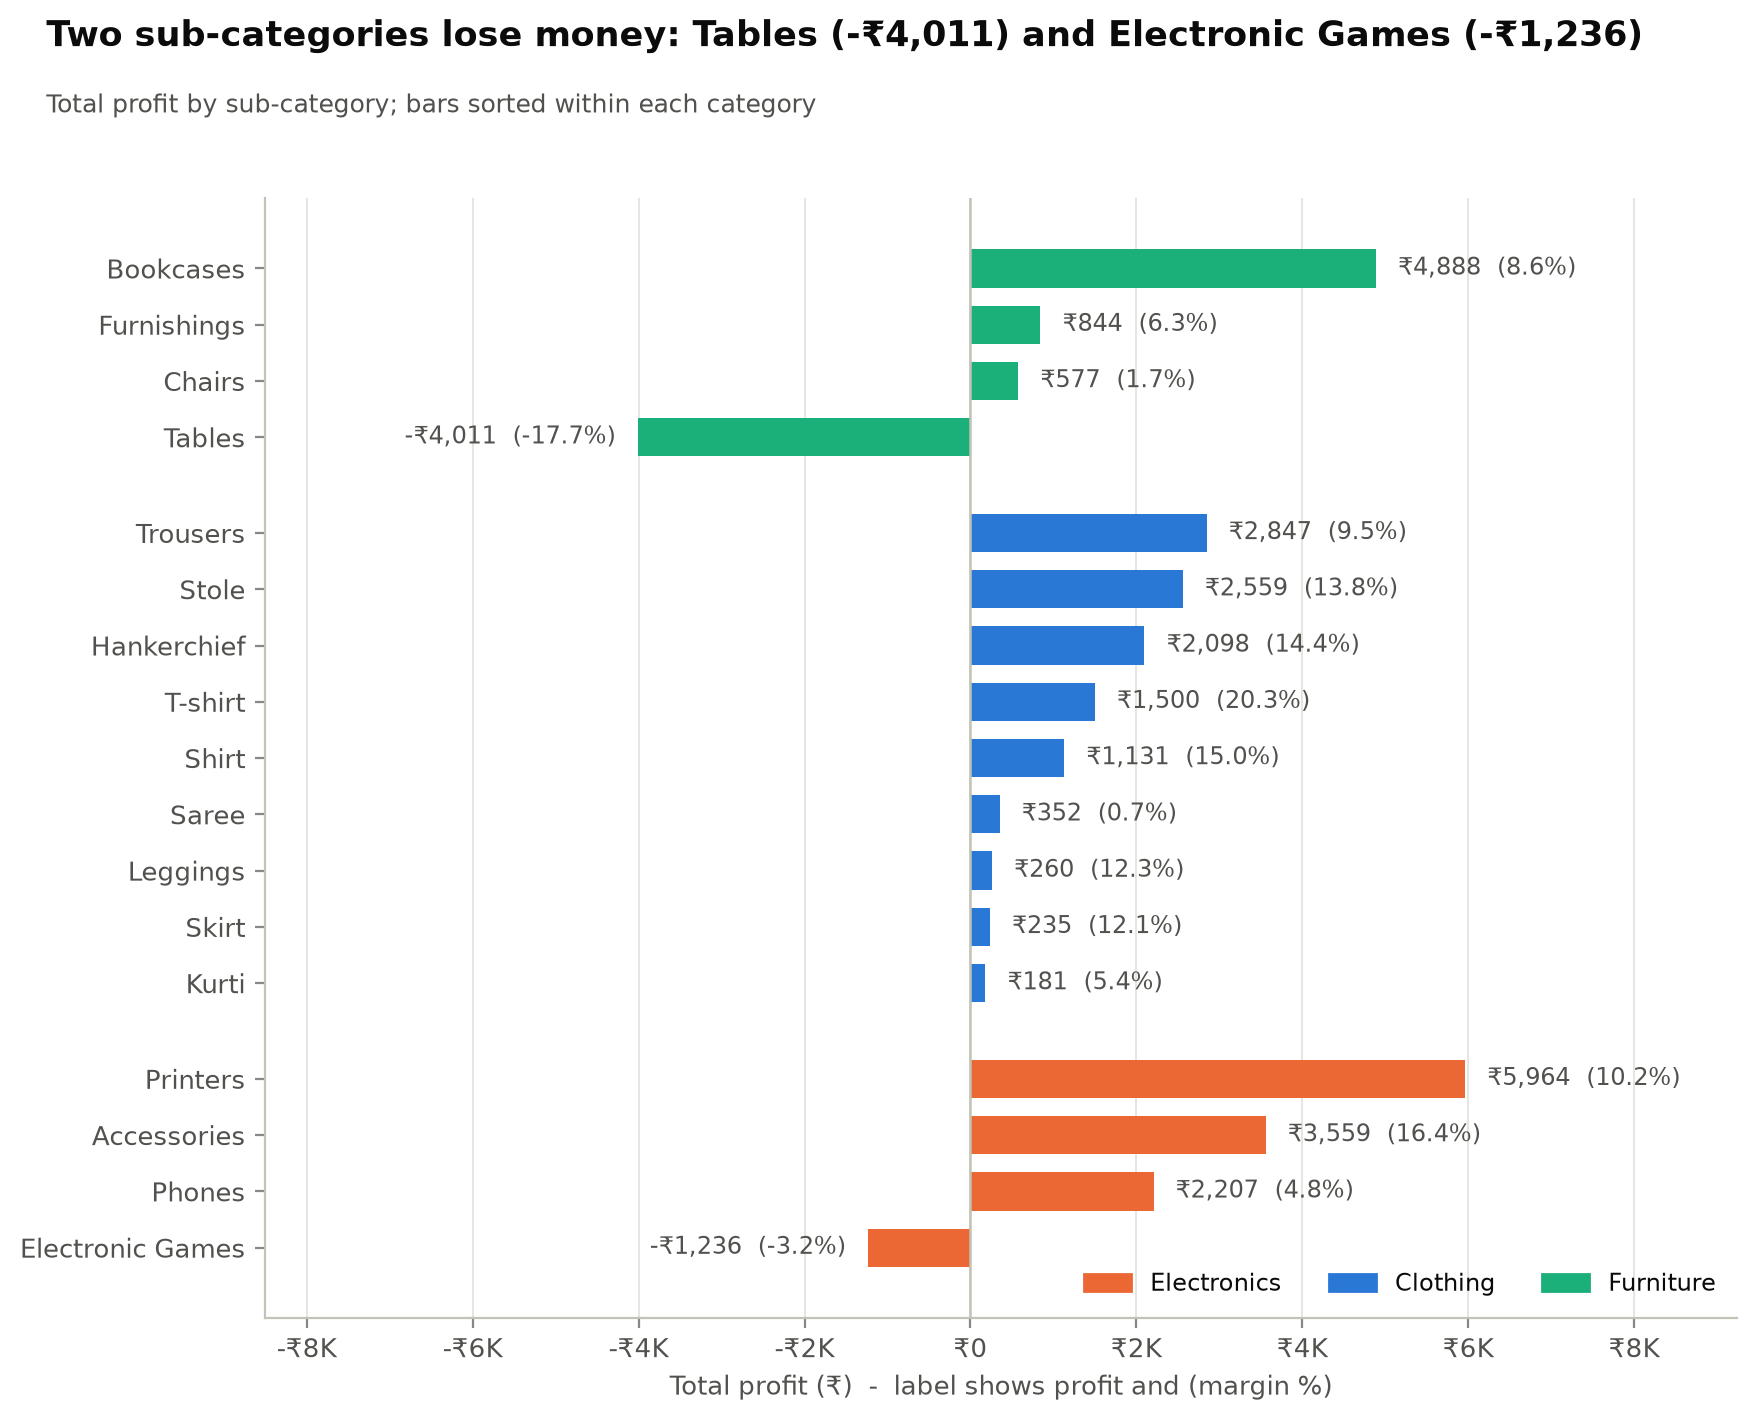

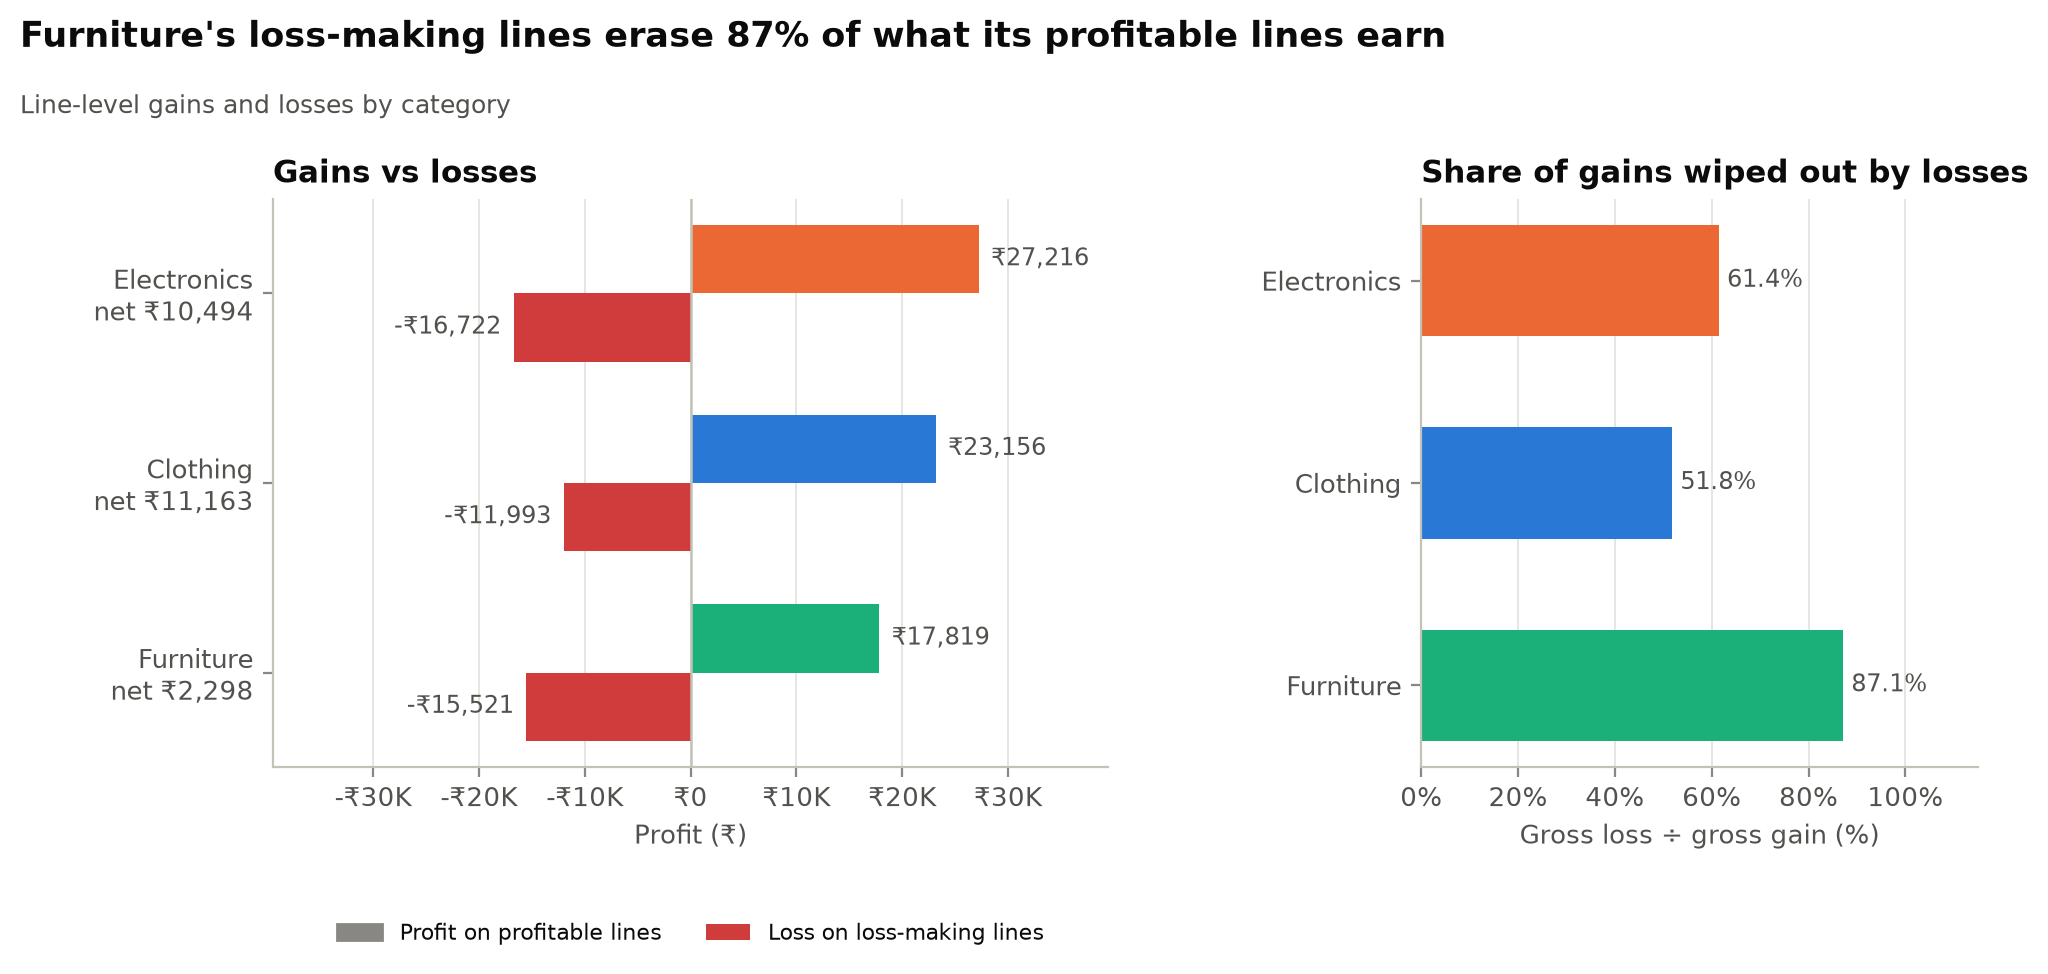

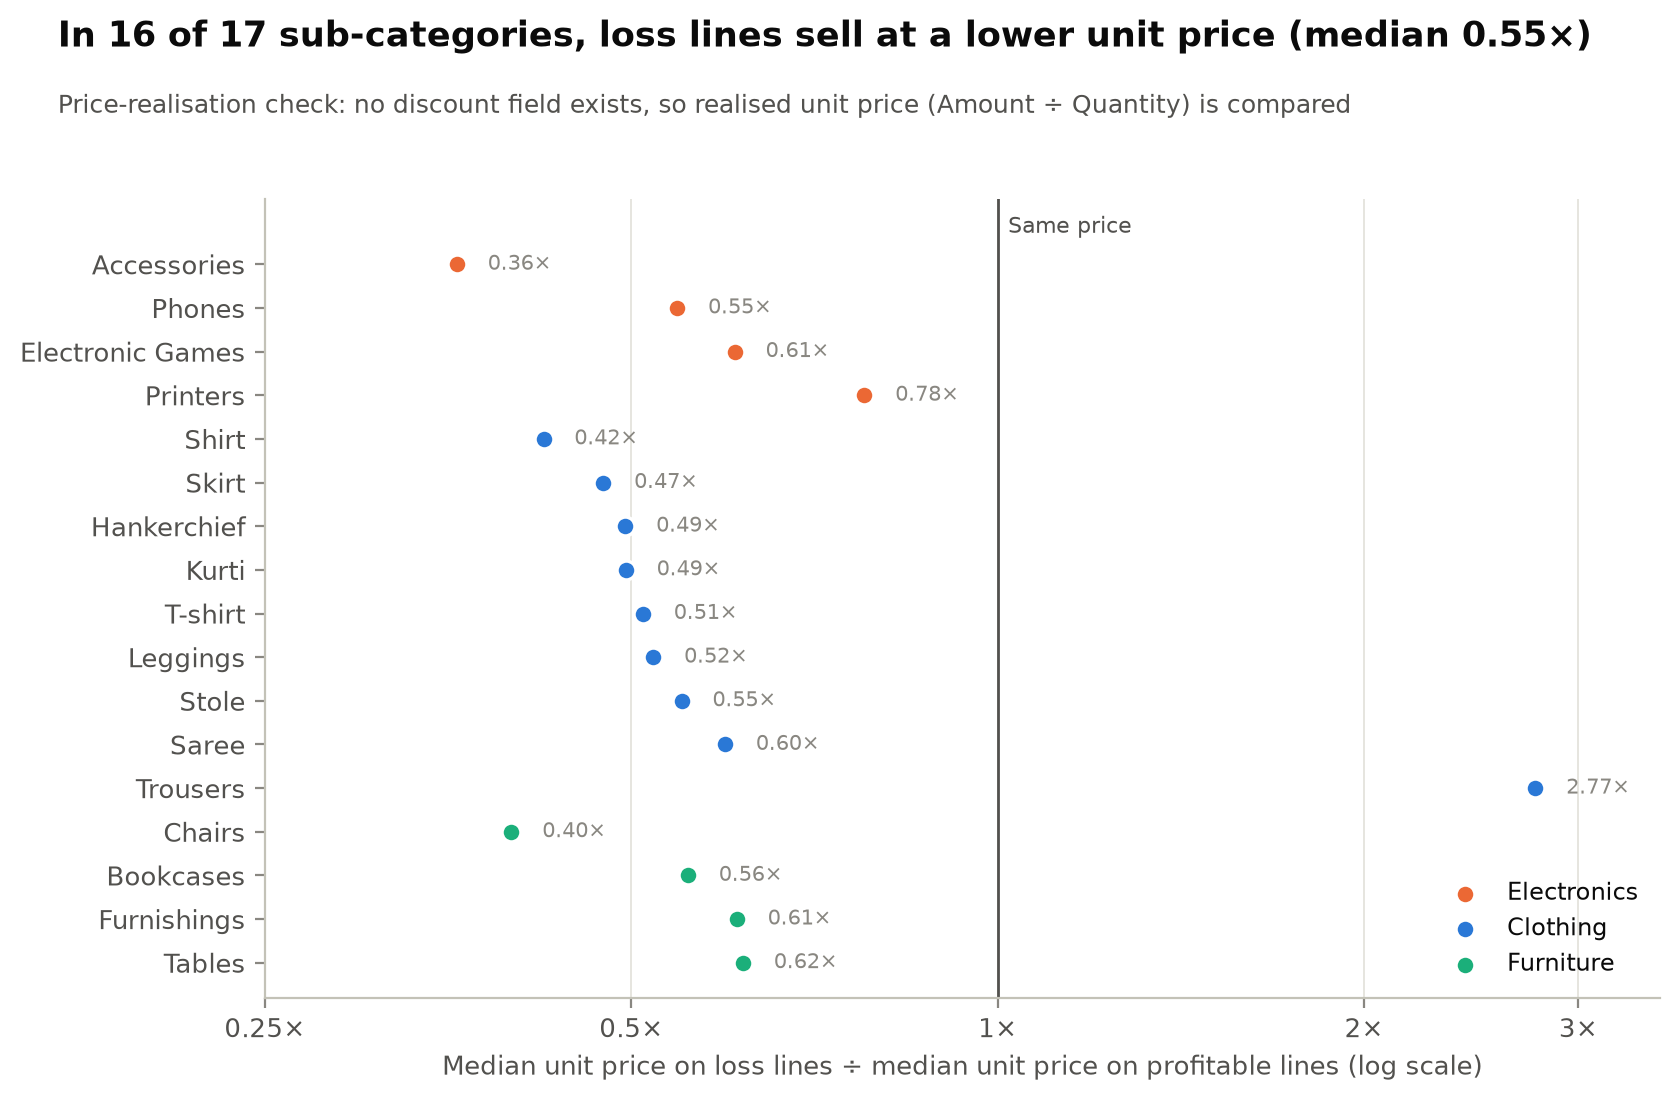

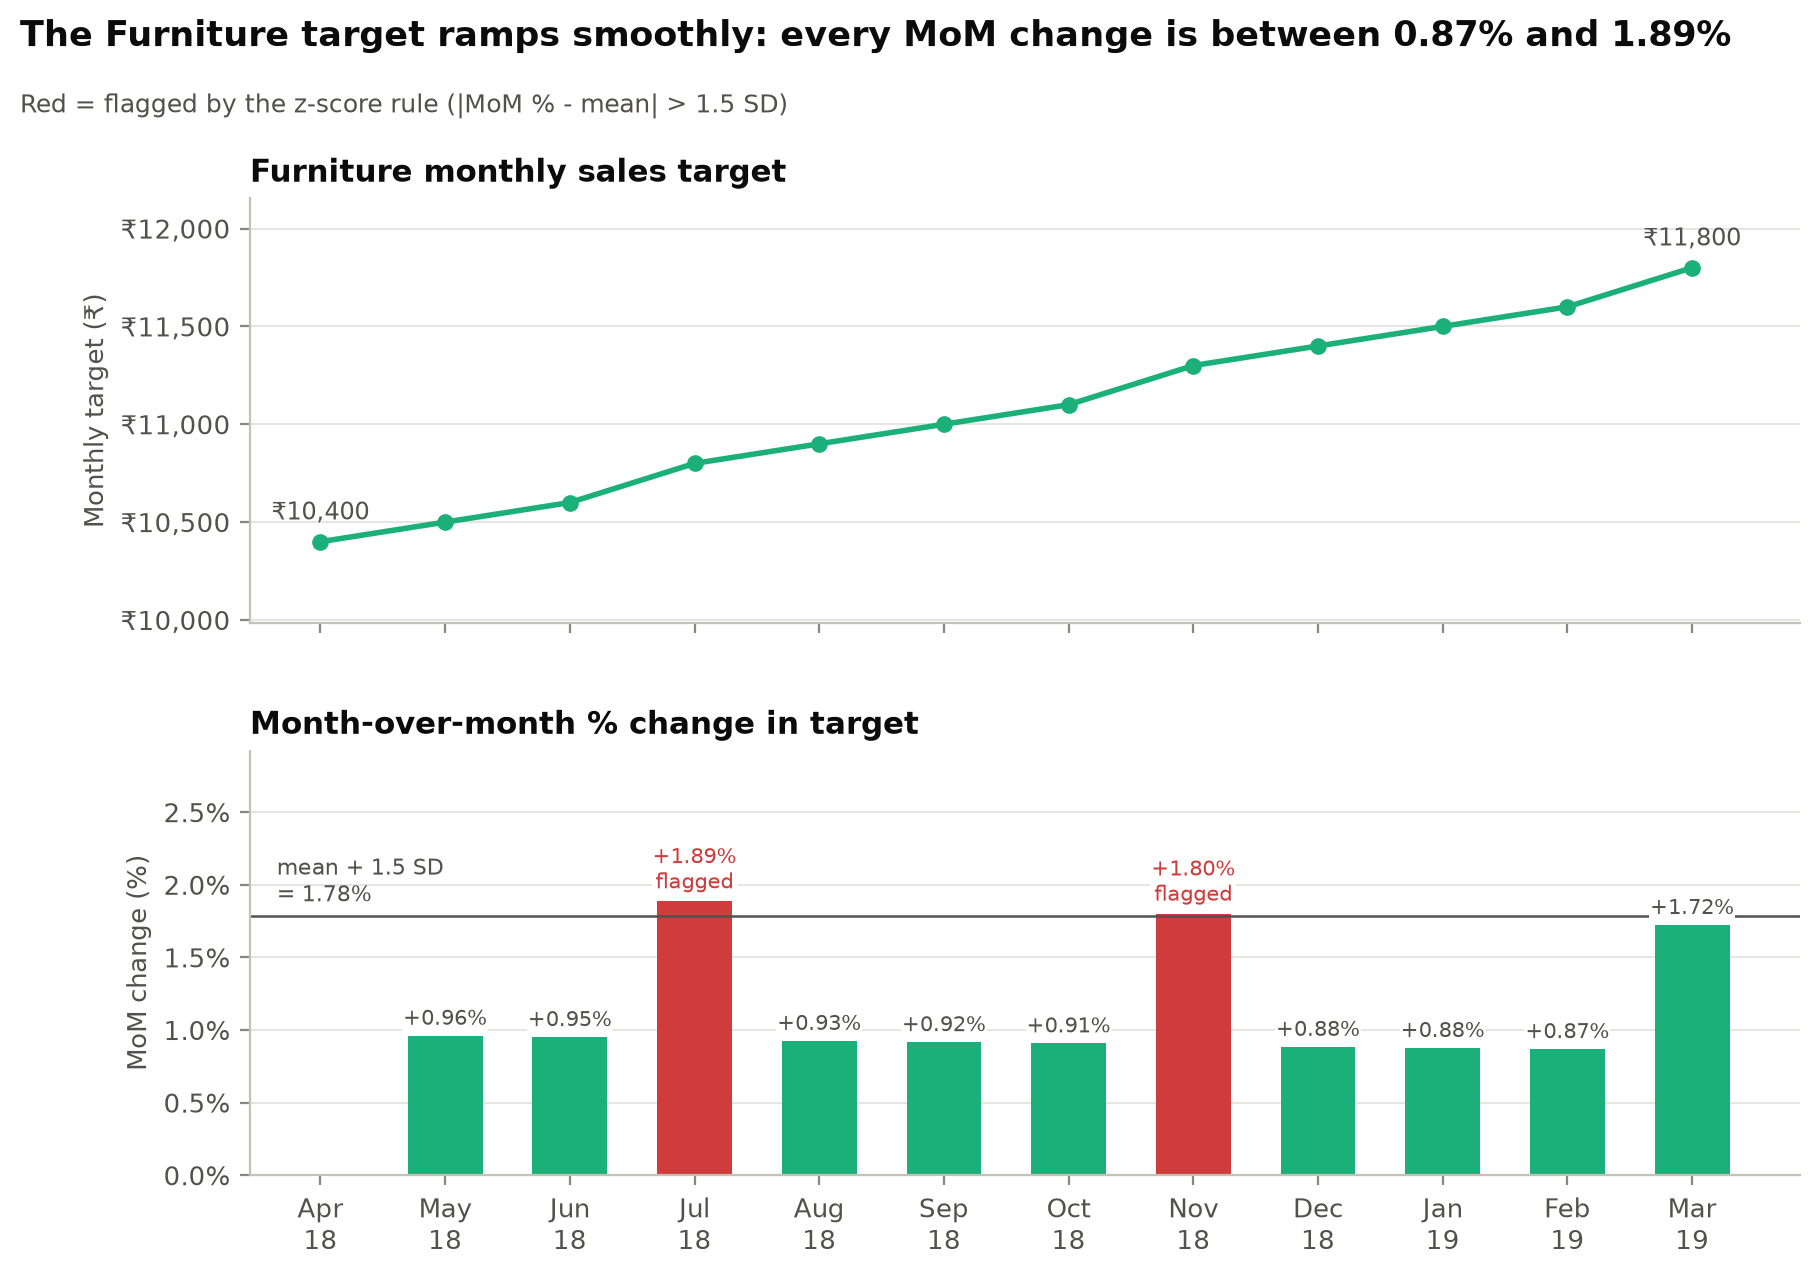

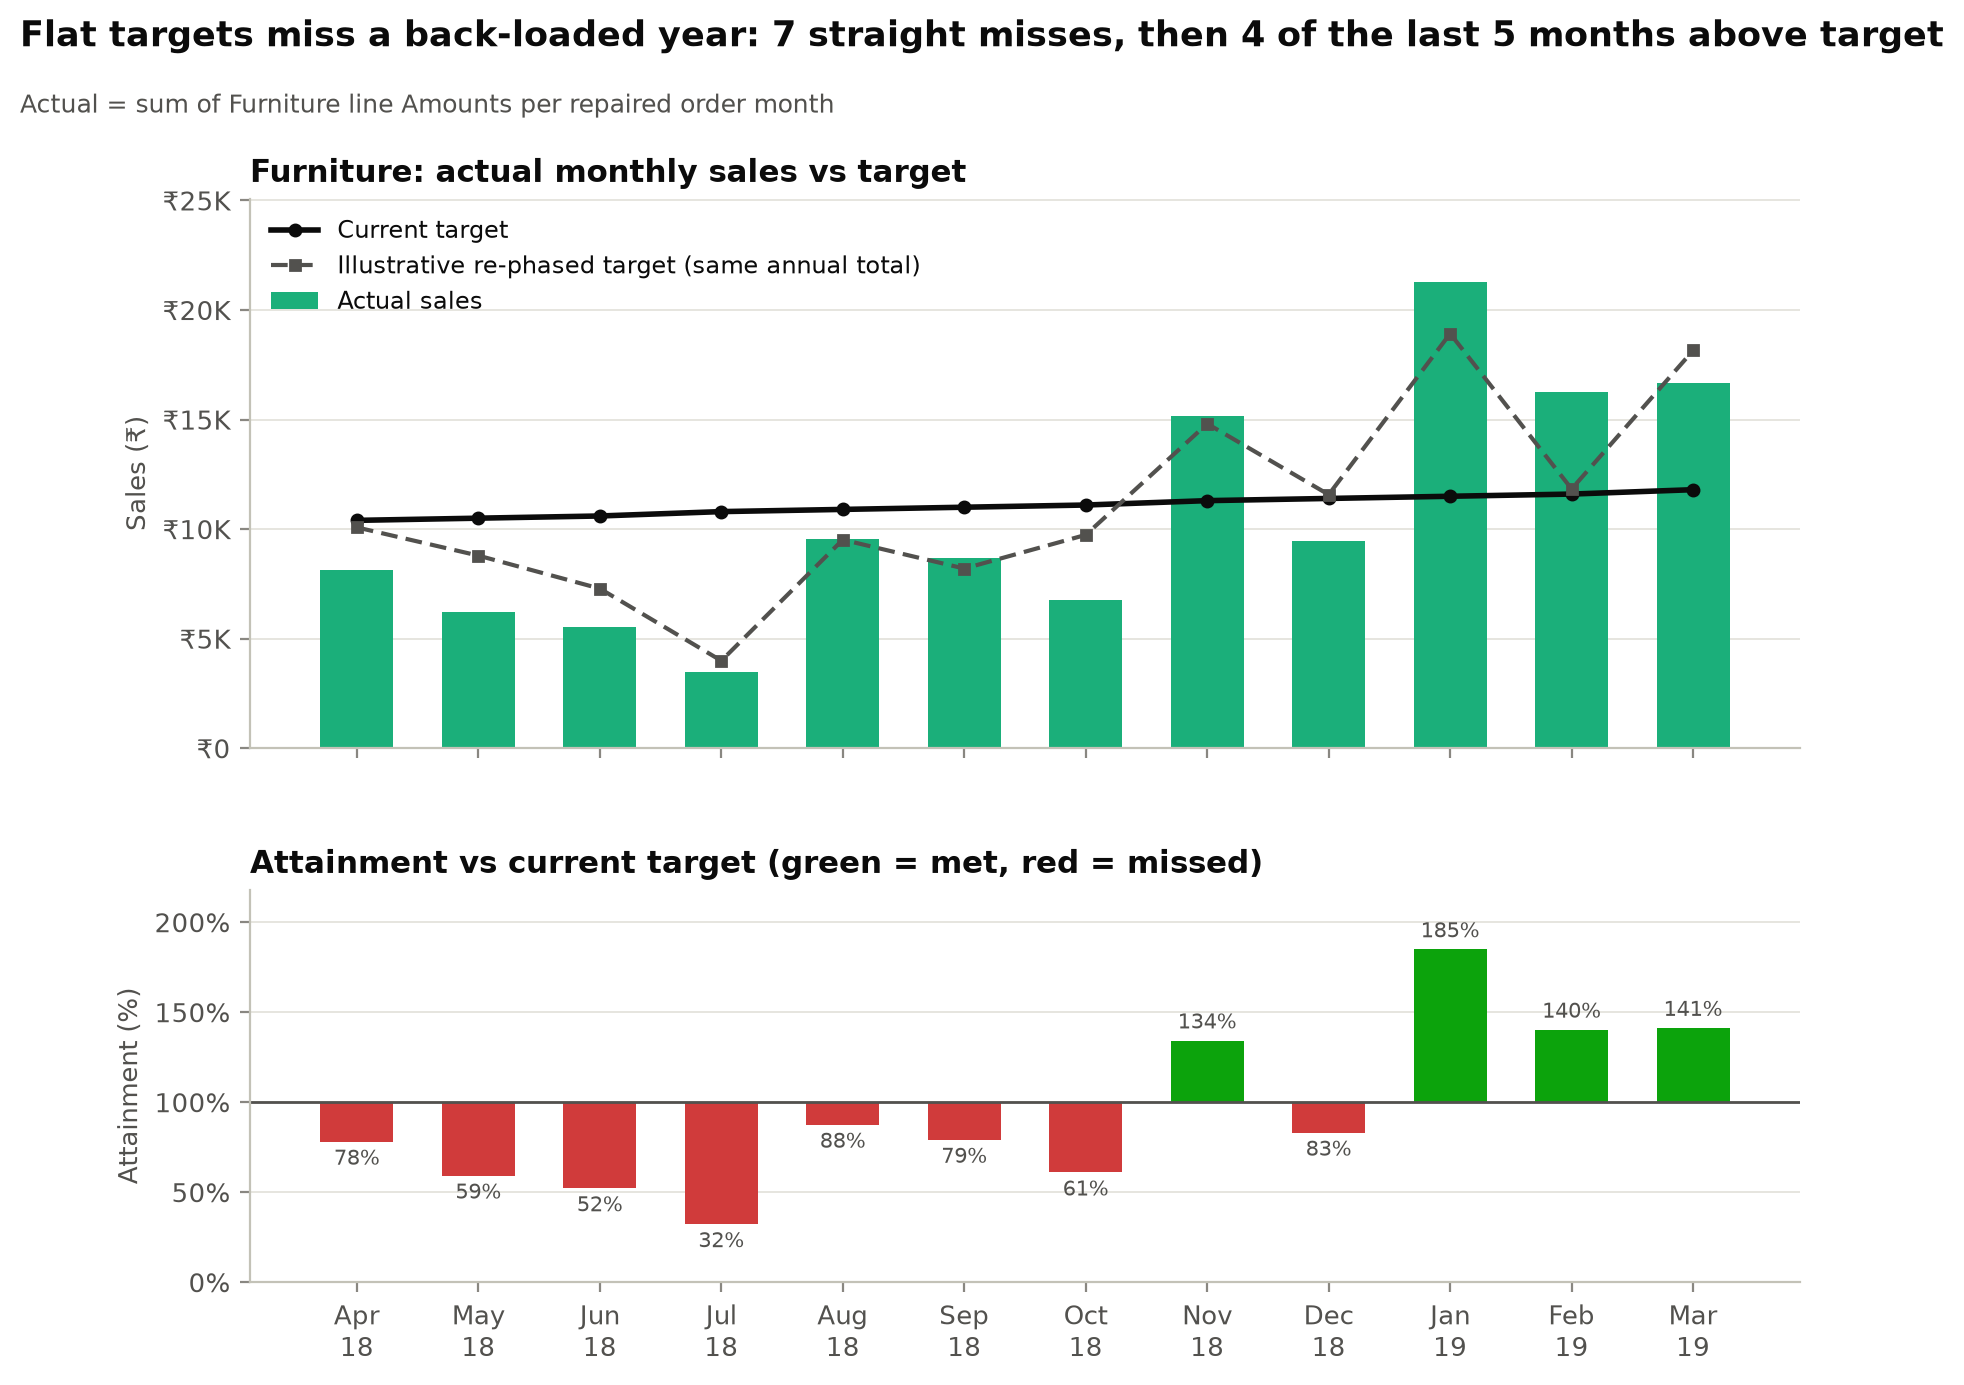

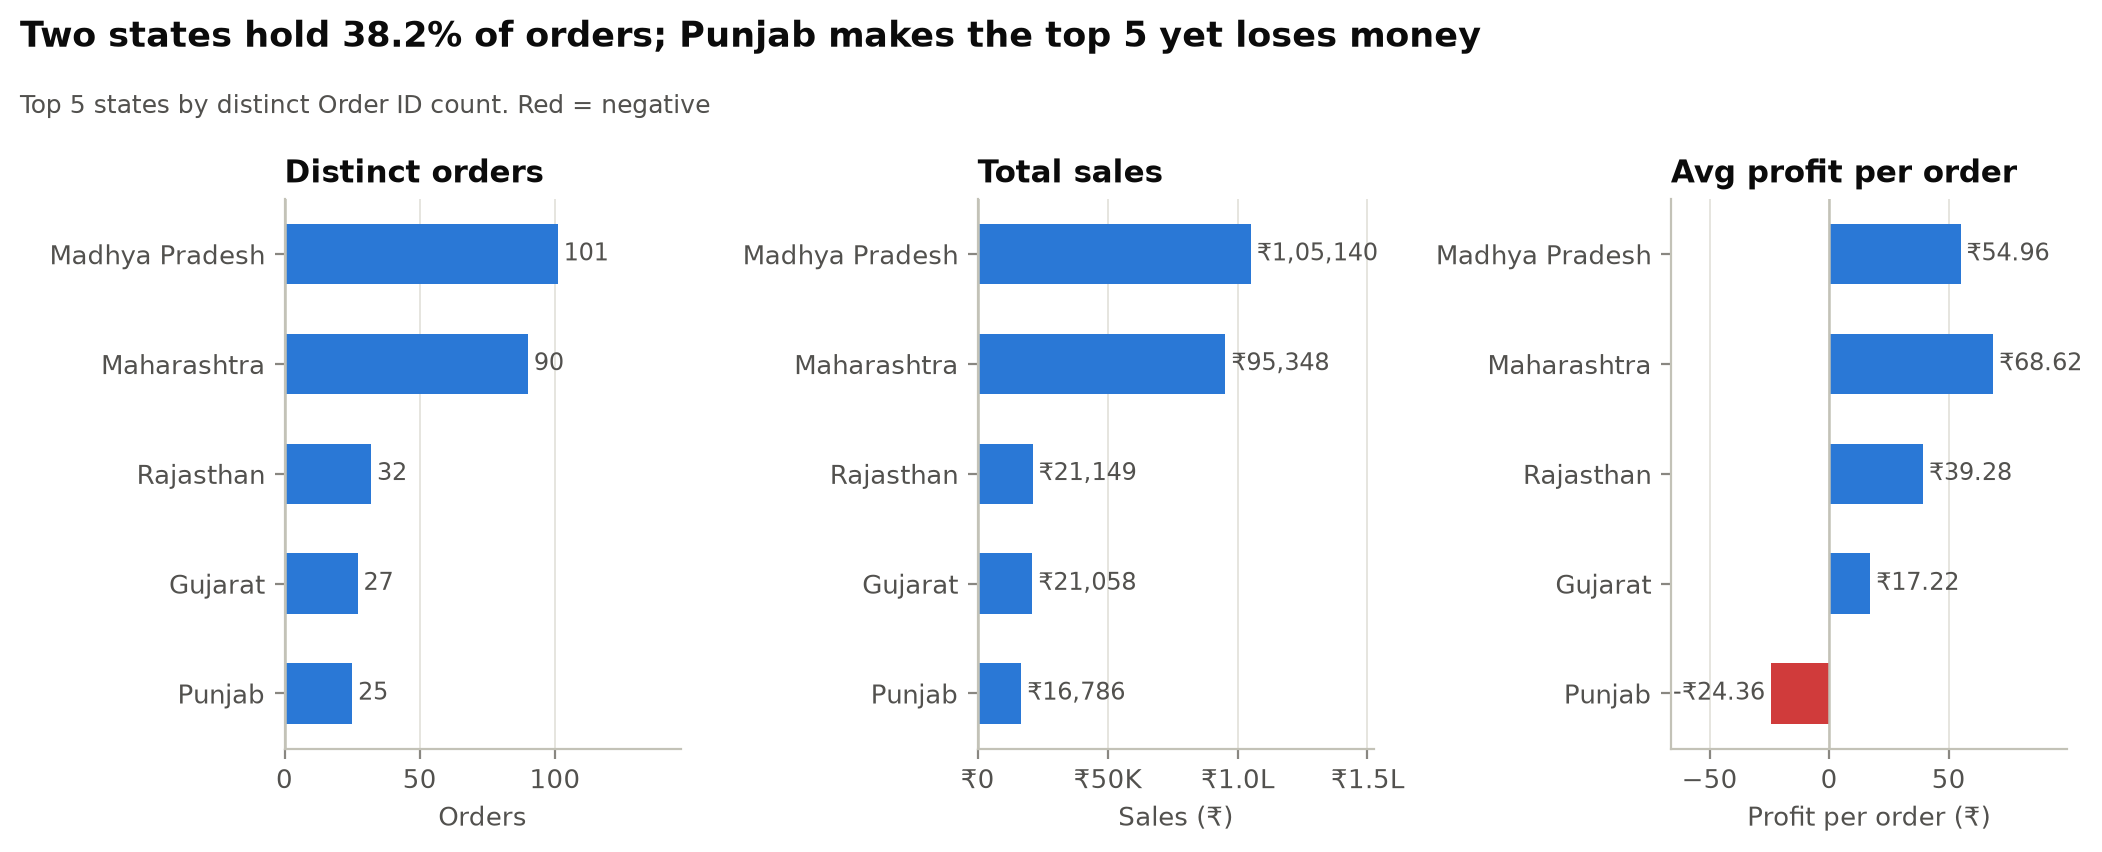

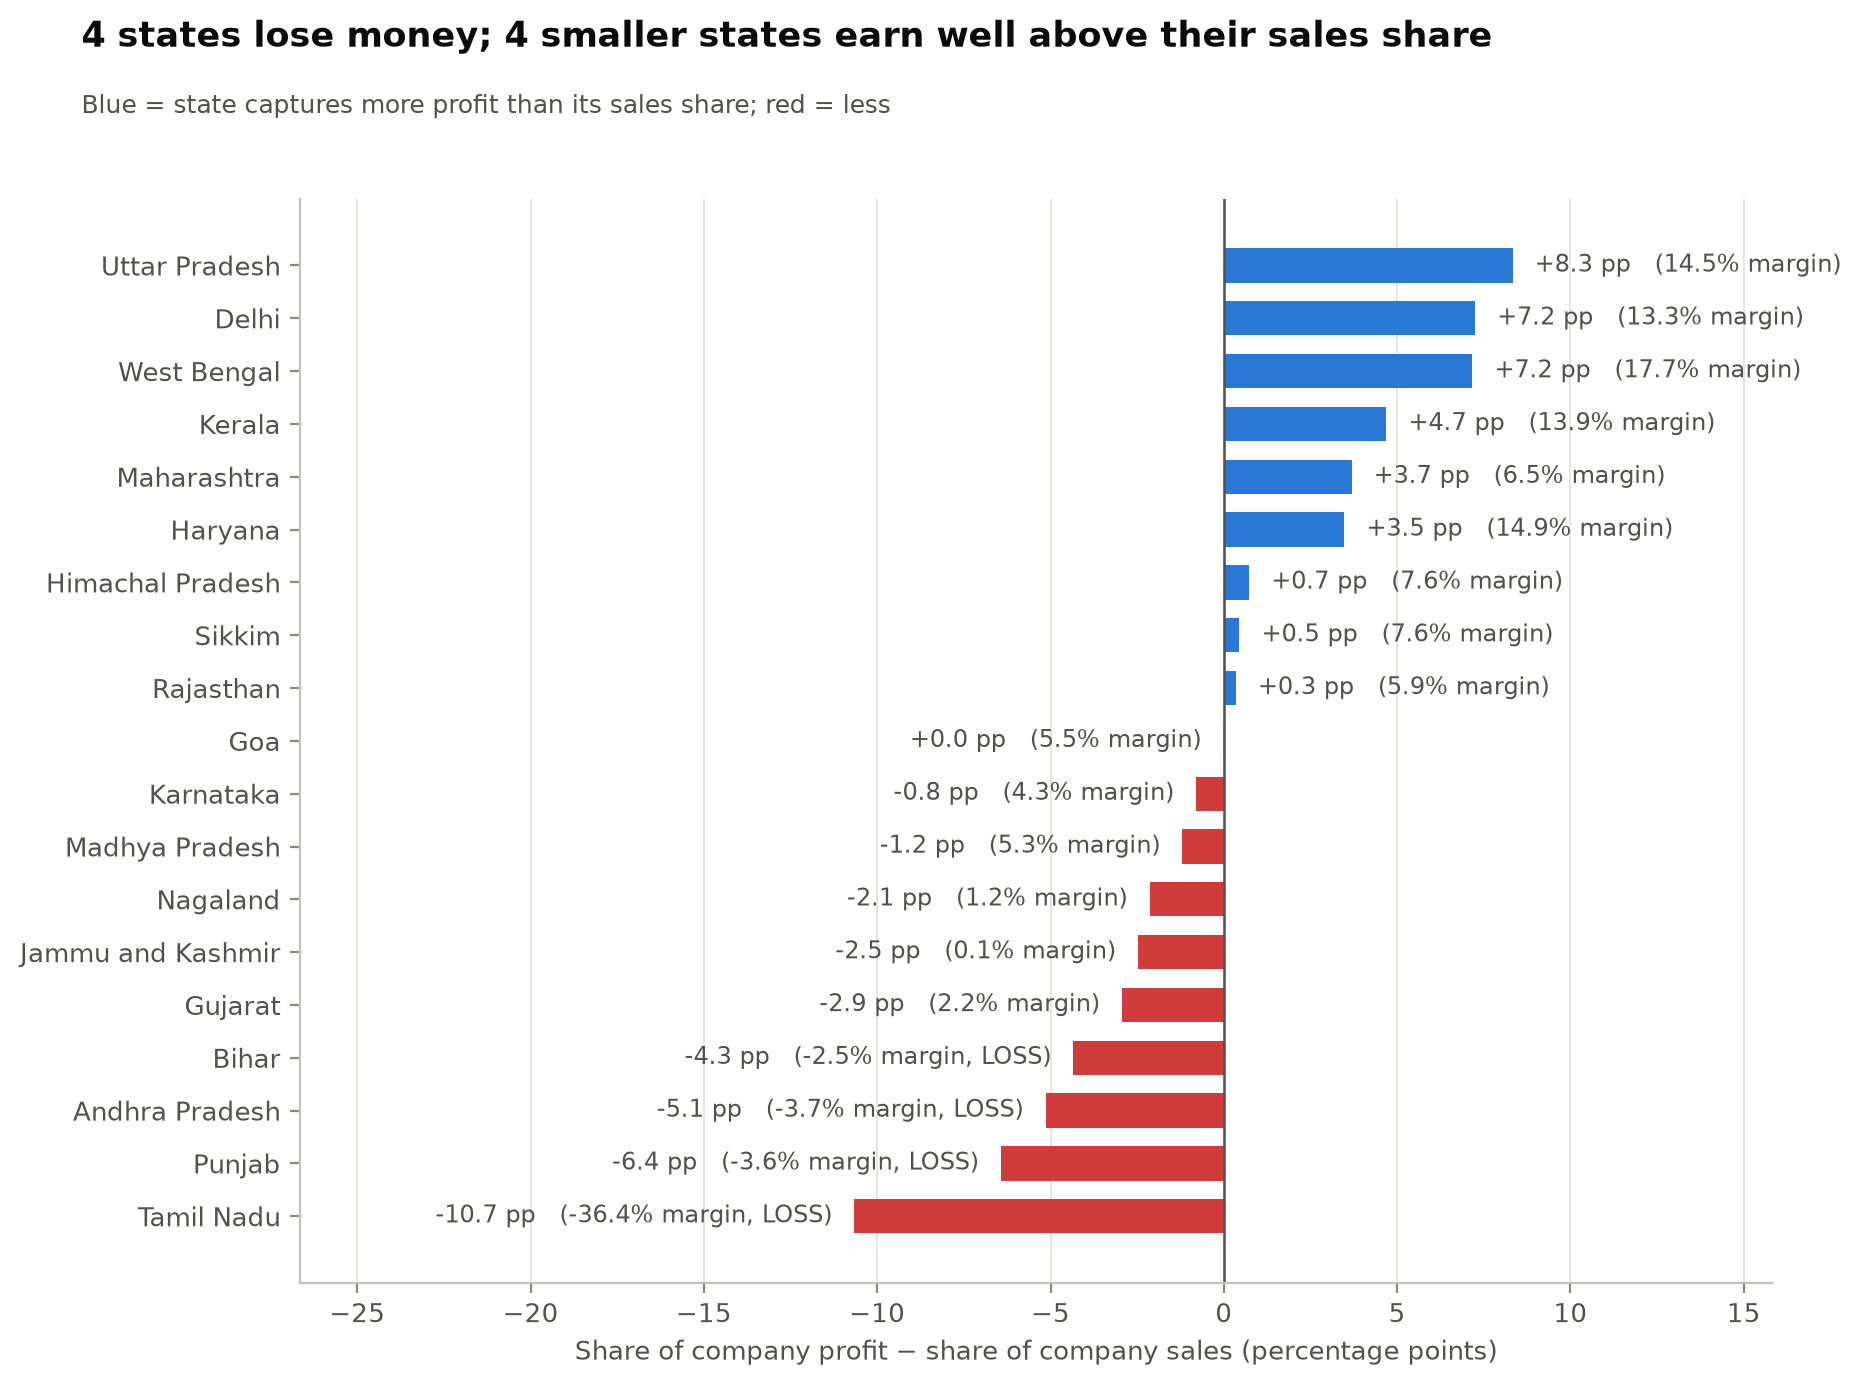

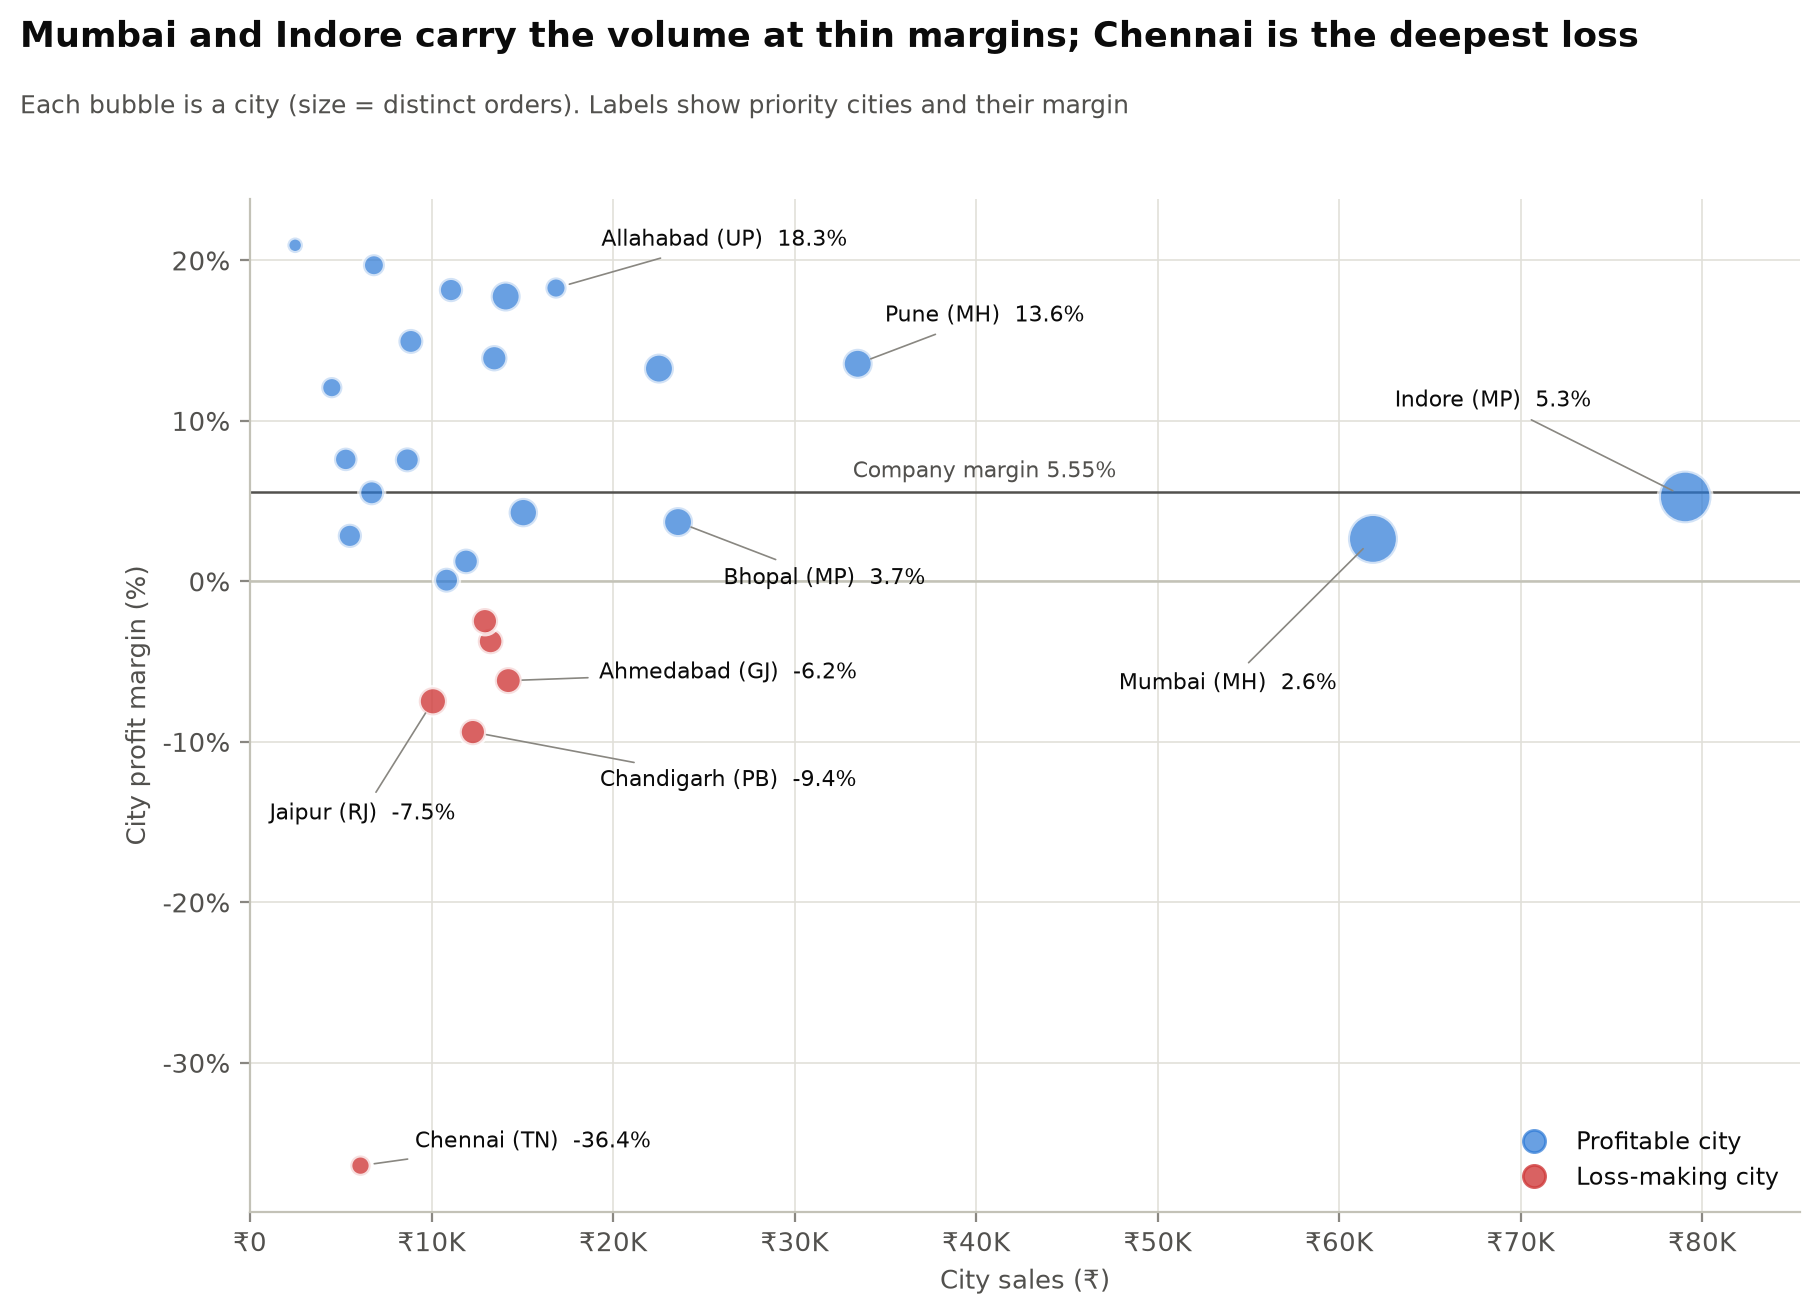

In [16]:
n = insights.build_numbers(t)
figs = pipeline.make_figures(t, n)
for key in [f'fig{i}' for i in range(1, 10)]:
    display(Image(filename=str(C.PROJECT_ROOT / figs[key]), width=900))